In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from scipy import stats
import seaborn as sns

import re
from collections import Counter

In [20]:
COL_LLAMA   = "#0011FF"
COL_QWEN   = "#FFAE00"
COL_FB    = '#C44E52'

In [21]:
df_llama = pd.read_csv('logs/llm_reward/LLAMA/rewards_log_LLAMA.csv')
df_qwen  = pd.read_csv('logs/llm_reward/QWEN/rewards_log_QWEN.csv')

df_llama['model'] = 'LLaMA 3.2:3b'
df_qwen['model']  = 'Qwen3:4b'

### Stats

In [31]:
def describe_reward(df, label):
    r_llm = df[df['source'] == 'llm']['reward']

    rows = []
    for name, series in [('LLM', r_llm)]:
        if len(series) == 0:
            continue
        rows.append({
            'Model'    : label,
            'Subset'   : name,
            'N'        : len(series),
            'Mean'     : series.mean(),
            'Median'   : series.median(),
            'Std'      : series.std(),
            'Min'      : series.min(),
            'Max'      : series.max(),
        })
    return rows

rows  = describe_reward(df_llama, 'LLaMA 3.2:3b')
rows += describe_reward(df_qwen,  'Qwen3:4b')

stats_df = pd.DataFrame(rows).set_index(['Model'])
float_cols = ['Mean','Median','Std','Min','Max']
display(stats_df[float_cols].style.format('{:.4f}'))

,Mean,Median,Std,Min,Max
Model,,,,,
LLaMA 3.2:3b,3.3131,4.0000,1.8238,-3.0000,5.0000
Qwen3:4b,3.0245,3.7500,1.8322,-2.0000,5.0000


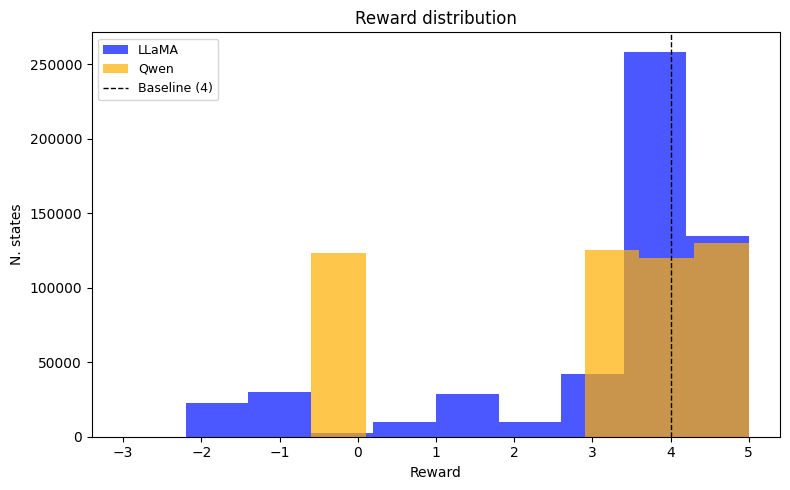

In [23]:
labels_bp = ['LLaMA', 'Qwen']
colors_bp = [COL_LLAMA, COL_QWEN]

fig, ax = plt.subplots(figsize=(8, 5))

ax.hist(df_llama['reward'].dropna(), color=COL_LLAMA, alpha=0.7, label='LLaMA')
ax.hist(df_qwen['reward'].dropna(), color=COL_QWEN,  alpha=0.7, label='Qwen')
ax.axvline(x=4, color='black', linestyle='--', linewidth=1, label='Baseline (4)')
ax.set_title('Reward distribution')
ax.set_xlabel('Reward')
ax.set_ylabel('N. states')
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('./logs/img/reward_error_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

### Evaluate rewards correctness

In [24]:
def parse_tag(tag):
    SIDE_MAP = {'LEFT': 'LEFT', 'RIGH': 'RIGHT', 'CENT': 'CENT'}
    result = {'hit': 'NONE', 'act': 'NONE', 'bullets': []}
    if pd.isna(tag):
        return result

    parts = [p.strip() for p in tag.split('|')]

    for part in parts:
        if part.startswith('HIT:'):
            result['hit'] = part[4:]
        elif part.startswith('ACT:'):
            result['act'] = part[4:]
        elif re.match(r'P\d+:', part):
            value = part.split(':', 1)[1].strip()
            if value == 'NONE':
                continue  
            fields = value.split(',')
            if len(fields) == 3:
                dist, side, direction = (f.strip() for f in fields)
                side = SIDE_MAP.get(side, side)
                result['bullets'].append((dist, side, direction))

    return result

def oracle(reward, parsed):
    action = parsed['act']

    # 1. No projectiles : every action is correct - reward should be positive
    if not parsed['bullets']:
        is_correct = reward > 0
        return is_correct

    concrete_threats = []
    for dist, side, direction in parsed['bullets']:
        if direction not in ('AWAY', 'PARA') and dist != 'DIST':
            concrete_threats.append((dist, side, direction))

    # 2. The threath is not concrete (AWAY/PARA or DIST): every action is correct
    if not concrete_threats:
        is_correct = reward > 0
        return is_correct

    # 3. Concrete threat (IMMI/APPR + TOWA) + Separate from PPO action choice:
    dist, side, direction = concrete_threats[0]
    if side == 'LEFT':
        action_correct = (action == "RIGHT")
        is_correct = (action_correct == (reward > 0))
        return is_correct
    elif side == 'RIGHT':
        action_correct = (action == "LEFT")
        is_correct = (action_correct == (reward > 0))
        return is_correct
    elif side == 'CENT':
        for next_bullet in concrete_threats[1:]:
            _, next_side, _ = next_bullet
            if next_side == 'LEFT':
                action_correct = (action == "RIGHT")
                is_correct = (action_correct == (reward > 0))
                return is_correct
            elif next_side == 'RIGHT':
                action_correct = (action == "LEFT")
                is_correct = (action_correct == (reward > 0))
                return is_correct
        return True
    # return True
    
def apply_oracle(df):
    df = df.copy()
    parsed_col = df['tag'].apply(parse_tag)

    correct_col = []
    for i, p in enumerate(parsed_col):
        reward = df.iloc[i]['reward']
        verdict = oracle(reward, p)
        correct_col.append(verdict)

    df['parsed'] = parsed_col
    df['is_correct'] = correct_col

    return df

df_llama = apply_oracle(df_llama)
df_qwen  = apply_oracle(df_qwen)

### Evaluate correctness distribution between llms

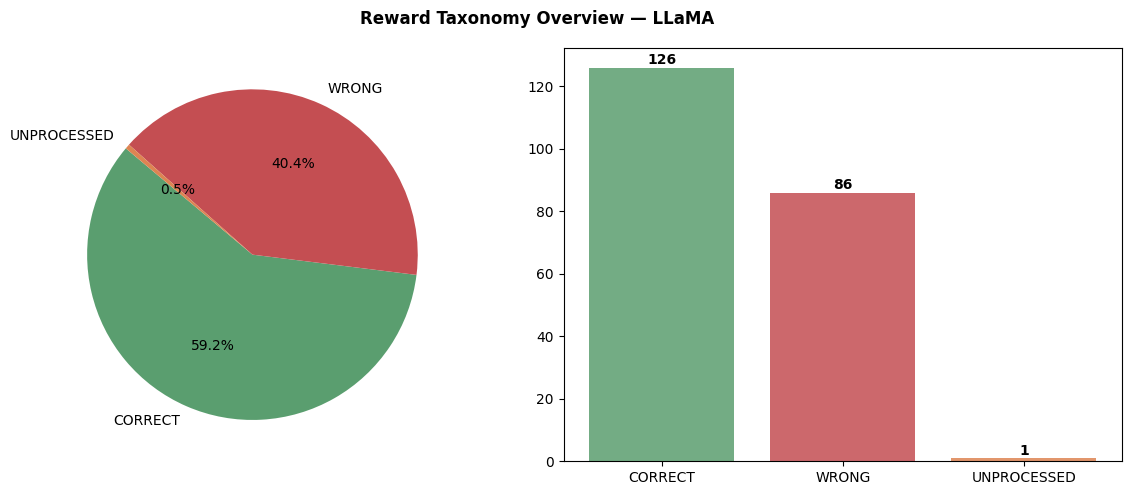

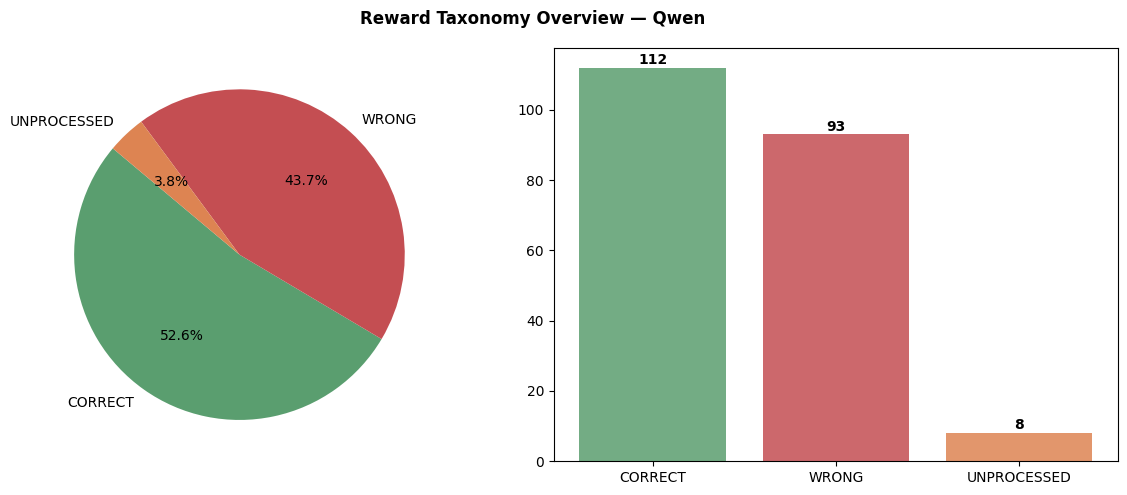

In [25]:
def build_reward_taxonomy(df, label):
    rows = []

    for tag, group in df.groupby('tag'):
        parsed = group['parsed'].iloc[0]
        np_val = len(parsed['bullets'])
        hit = parsed['hit']
        p1 = parsed['bullets'][0] if parsed['bullets'] else (None, None, None)
        p1_dist, p1_side, p1_dir = p1

        llm_rows = group[group['source'] == 'llm']
        fb_rows = group[group['source'] == 'ppo_fallback']
        n_fb = len(fb_rows)

        base = {
            'tag': tag,
            'model': label,
            'n_fallback': n_fb,
            'hit': hit,
            'np_val': np_val,
            'p1_dist': p1_dist,
            'p1_side': p1_side,
            'p1_dir': p1_dir,
        }

        if len(llm_rows) == 0:
            rows.append({**base,
                'status': 'UNPROCESSED',
                'reward': np.nan,
            })
        else:
            llm_row = llm_rows.iloc[0]
            rows.append({**base,
                'status': 'CORRECT' if llm_row['is_correct'] else 'WRONG',
                'reward': llm_row['reward'],
            })

    return pd.DataFrame(rows).set_index('tag')

def plot_taxonomy_overview(tax, label, title = None):
    counts = tax['status'].value_counts()
    status_colors = {
        'CORRECT': '#5A9E6F',
        'WRONG': '#C44E52',
        'UNPROCESSED': '#DD8452',
    }
    colors = [status_colors.get(s, '#333') for s in counts.index]

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    if title is None:
        fig.suptitle(f'Reward Taxonomy Overview — {label}', fontweight='bold', fontsize=12)
    else:
        fig.suptitle(title, fontweight='bold', fontsize=12)

    # Pie
    wedges, texts, autotexts = axes[0].pie(
        counts.values,
        labels=counts.index,
        colors=colors,
        autopct='%1.1f%%',
        startangle=140,
        textprops={'fontsize': 10},
    )

    # Bar
    bars = axes[1].bar(counts.index, counts.values, color=colors, alpha=0.85)
    for bar, val in zip(bars, counts.values):
        axes[1].text(bar.get_x() + bar.get_width()/2,
                     bar.get_height() + len(tax)*0.005,
                     str(val), ha='center', fontsize=10, fontweight='bold')

    plt.tight_layout()
    fname = f'./logs/img/reward_taxonomy_overview_{label.replace(" ","_").replace(":","")}.png'
    plt.savefig(fname, dpi=150, bbox_inches='tight')
    plt.show()

tax_llama = build_reward_taxonomy(df_llama, 'LLaMA')
tax_qwen  = build_reward_taxonomy(df_qwen,  'Qwen')

for tax, lbl in [(tax_llama, 'LLaMA'), (tax_qwen, 'Qwen')]:
    plot_taxonomy_overview(tax, lbl)

### Errors analysis

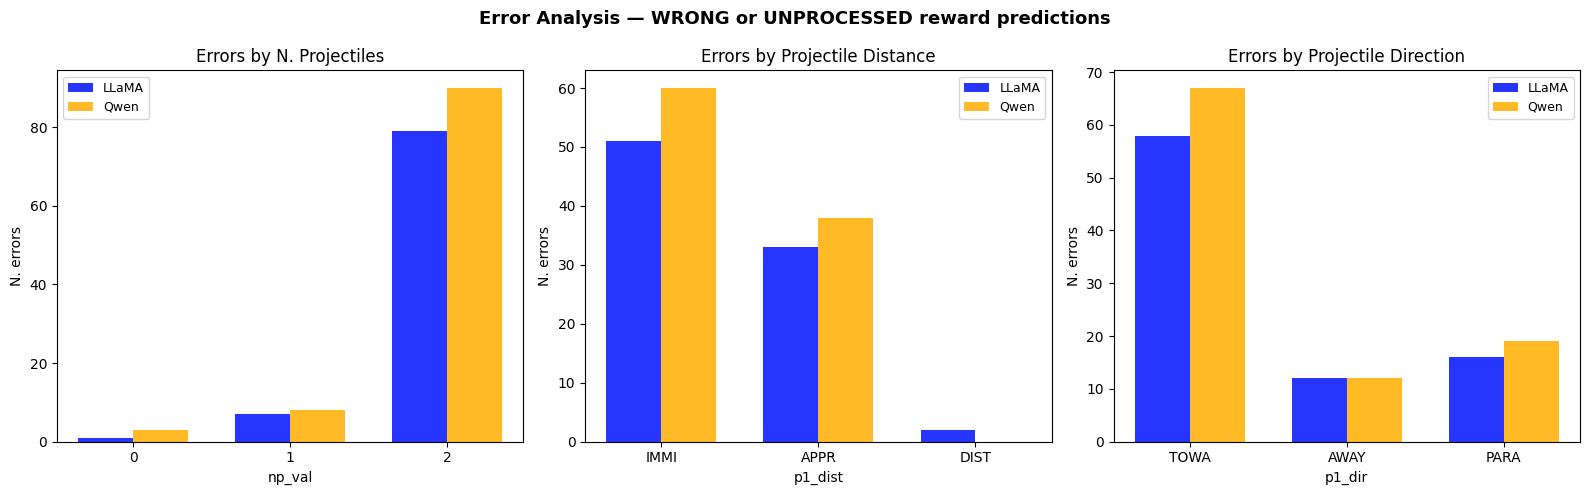

In [30]:
def plot_error_analysis(tax_llama, tax_qwen):
    # Considering both wrong or unprocessed states as errors
    wrong_llama = tax_llama[tax_llama['status'] != 'CORRECT']
    wrong_qwen  = tax_qwen[tax_qwen['status']  != 'CORRECT']

    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    fig.suptitle('Error Analysis — WRONG or UNPROCESSED reward predictions', fontweight='bold', fontsize=13)

    w = 0.35

    # Errors vs number of projectiles
    ax = axes[0]
    llama_np = wrong_llama['np_val'].value_counts().sort_index()
    qwen_np  = wrong_qwen['np_val'].value_counts().sort_index()
    np_vals  = sorted(set(llama_np.index) | set(qwen_np.index))
    x = np.arange(len(np_vals))
    ax.bar(x - w/2, [llama_np.get(n, 0) for n in np_vals], width=w, color=COL_LLAMA, alpha=0.85, label='LLaMA')
    ax.bar(x + w/2, [qwen_np.get(n, 0)  for n in np_vals], width=w, color=COL_QWEN,  alpha=0.85, label='Qwen')
    ax.set_xticks(x)
    ax.set_xticklabels([str(n) for n in np_vals])
    ax.set_title('Errors by N. Projectiles')
    ax.set_xlabel('np_val')
    ax.set_ylabel('N. errors')
    ax.legend(fontsize=9)

    # Errors vs 1st projectile distance
    ax = axes[1]
    dist_order = ['IMMI', 'APPR', 'DIST']
    llama_dist = wrong_llama['p1_dist'].value_counts().reindex(dist_order, fill_value=0)
    qwen_dist  = wrong_qwen['p1_dist'].value_counts().reindex(dist_order, fill_value=0)
    x = np.arange(len(dist_order))
    ax.bar(x - w/2, llama_dist, width=w, color=COL_LLAMA, alpha=0.85, label='LLaMA')
    ax.bar(x + w/2, qwen_dist,  width=w, color=COL_QWEN,  alpha=0.85, label='Qwen')
    ax.set_xticks(x)
    ax.set_xticklabels(dist_order)
    ax.set_title('Errors by Projectile Distance')
    ax.set_xlabel('p1_dist')
    ax.set_ylabel('N. errors')
    ax.legend(fontsize=9)

    # Errors vs 1st projectile direction - action  made
    ax = axes[2]
    dir_order = ['TOWA', 'AWAY', 'PARA']
    llama_dir = wrong_llama['p1_dir'].value_counts().reindex(dir_order, fill_value=0)
    qwen_dir  = wrong_qwen['p1_dir'].value_counts().reindex(dir_order, fill_value=0)
    x = np.arange(len(dir_order))
    ax.bar(x - w/2, llama_dir, width=w, color=COL_LLAMA, alpha=0.85, label='LLaMA')
    ax.bar(x + w/2, qwen_dir,  width=w, color=COL_QWEN,  alpha=0.85, label='Qwen')
    ax.set_xticks(x)
    ax.set_xticklabels(dir_order)
    ax.set_title('Errors by Projectile Direction')
    ax.set_xlabel('p1_dir')
    ax.set_ylabel('N. errors')
    ax.legend(fontsize=9)

    plt.tight_layout()
    plt.savefig('./logs/img/reward_error_analysis.png', dpi=150, bbox_inches='tight')
    plt.show()

plot_error_analysis(tax_llama, tax_qwen)